In [1]:
import qiskit
import qiskit_ibm_runtime

print(qiskit.version.get_version_info())
print(qiskit_ibm_runtime.version.get_version_info())

2.2.2
0.37.0


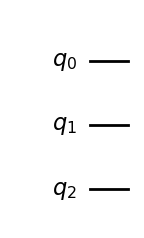

In [2]:
from qiskit.circuit import QuantumCircuit

# A quantum circuit with three qubits
qc = QuantumCircuit(3)
qc.draw('mpl')

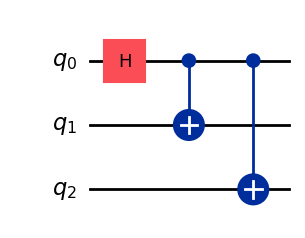

In [3]:
# Hadamard gate on qubit 0.
qc.h(0)
# CX gates on qubits (0, 1) and (0, 2).
qc.cx(0, 1)
qc.cx(0, 2)

qc.draw('mpl')

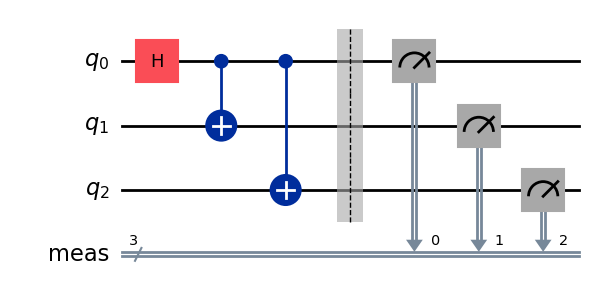

In [4]:
qc.measure_all()
qc.draw('mpl')

### Simulation

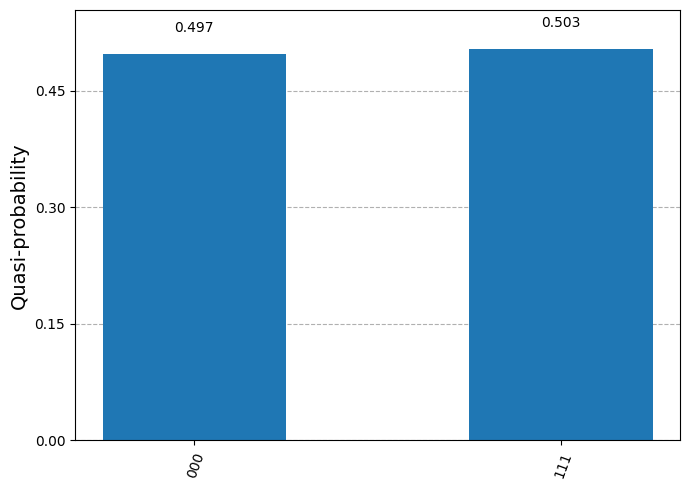

In [11]:
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_distribution

sampler = StatevectorSampler()
pm = generate_preset_pass_manager(optimization_level=1)
# Generate the ISA circuit
qc_isa = pm.run(qc)
# Run the simulator 10_000 times
num_shots = 10_000
result = sampler.run([qc_isa], shots=num_shots).result()[0]
# Collect and plot measurements
measurements= result.data.meas.get_counts()
plot_distribution(measurements)

In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService(name="school-main")
# Fetch a QPU to use
backend = service.backend("ibm_brisbane")
target = backend.target
sampler = Sampler(mode=backend)
pm = generate_preset_pass_manager(target=target, optimization_level=1)
# Generate the ISA circuit
qc_isa = pm.run(qc)

In [15]:
# Run the simulator 10_000 times
num_shots = 10_000
result = sampler.run([qc_isa], shots=num_shots).result()[0]

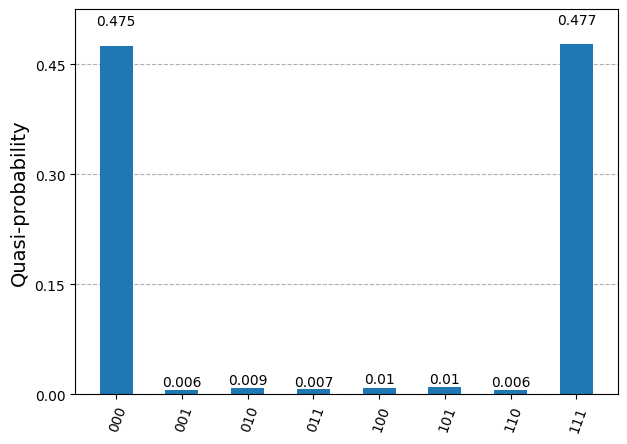

In [16]:
# Collect and plot measurements
measurements= result.data.meas.get_counts()
plot_distribution(measurements)

In [ ]:
def run_circuit(
        qc: QuantumCircuit, 
        service: QiskitRuntimeService = service, 
        num_shots: int = 100,
    ) -> tuple[dict[str, int], QuantumCircuit]:
    """Runs the circuit on backend 'num_shots' times. Returns the counts of 
    measurements and the ISA circuit."""
    # Fetch an available QPU
    backend = service.least_busy(operational=True, simulator=False)
    target = backend.target
    pm = generate_preset_pass_manager(target=target, optimization_level=1)
    
    # Add qubit mesurement layer and compute ISA circuit
    qc_meas = qc.measure_all(inplace=False)
    qc_isa = pm.run(qc_meas)

    # Run the ISA circuit and collect results
    sampler = Sampler(mode=backend)
    result = sampler.run([qc_isa], shots=num_shots).result()
    dist = result[0].data.meas.get_counts()

    return dist, qc_isa